# Thesis Figure 2 â€” Seed Selection

Runs the **initial segment scoring scan** (surrogate dataset) and visualises which
segment is selected as the seed and which are its immediate neighbours
(the first set of candidate "actions").

Output figure: score heatmap with
- **â˜… gold star** â€” seed segment (highest |score|)
- **â— white circles** â€” immediate frontier neighbours of the seed

Edit only the **Configuration** cell.

In [ ]:
# â”€â”€ Configuration â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
IMAGE_PATH = r"REPO_ROOT/images\\images\\imagenets_0082.jpg"

OVERRIDES = [
    "segmentation=slic",  # hexagonal | slic | square
    "segmentation.n_segments=300",  # e.g. hex_radius for hexagonal
    "segmentation.compactness=20",
    "replacement=imagenet_mean",
]

TARGET_CLASS_IDX = None  # None â†’ use the model's top-1 predicted class
SIGMA = 1  # seed mode: None=max|score|, 1=positive, -1=negative
NEIGHBORHOOD_DIST = 1  # BFS distance for score smoothing (matches CIAO default)
BATCH_SIZE = 16

# Visual settings
SCORE_ALPHA = 0.55  # opacity of score heatmap overlay
SEED_MARKER_SIZE = 18  # star size
NEIGHBOR_MARKER_SIZE = 10  # circle size for frontier neighbours

OUTPUT_DIR = "output"

In [ ]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from hydra import compose, initialize_config_dir
from hydra.core.global_hydra import GlobalHydra
from hydra.utils import instantiate


REPO_ROOT = Path("../..").resolve()
sys.path.insert(0, str(REPO_ROOT))

from ciao.algorithm.builder import _select_seed_and_sign
from ciao.data.preprocessing import load_and_preprocess_image
from ciao.model.predictor import ModelPredictor
from ciao.scoring.region import log_odds_for_class
from ciao.scoring.segments import calculate_segment_scores, create_surrogate_dataset
from ciao.visualization.visualization import _segment_boundaries, _to_hwc


OUT = Path(OUTPUT_DIR)
OUT.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")

device: cpu


In [ ]:
# â”€â”€ Load image, model and segmentation via Hydra â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
GlobalHydra.instance().clear()
with initialize_config_dir(config_dir=str(REPO_ROOT / "configs"), version_base=None):
    cfg = compose(config_name="base", overrides=OVERRIDES)

img_tensor = load_and_preprocess_image(IMAGE_PATH, device=device)
input_batch = img_tensor.unsqueeze(0)

segmentation_fn = instantiate(cfg.segmentation)
image_graph = segmentation_fn(img_tensor)

model = instantiate(cfg.model).to(device).eval()
class_names = instantiate(cfg.classes)
predictor = ModelPredictor(model=model, class_names=class_names)

replacement_fn = instantiate(cfg.replacement)
replacement_image = replacement_fn(img_tensor)

img_np = _to_hwc(input_batch)
segs = image_graph.segments.cpu().numpy()

print(f"Segments: {image_graph.num_segments}")

Segments: 281


In [ ]:
# â”€â”€ Run model & compute surrogate segment scores â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
with torch.no_grad():
    logits = predictor.get_logits(input_batch)

if TARGET_CLASS_IDX is None:
    target_class_idx = int(logits.argmax(dim=1)[0].item())
else:
    target_class_idx = TARGET_CLASS_IDX

class_label = class_names[target_class_idx] if class_names else str(target_class_idx)
prob = float(torch.softmax(logits, dim=1)[0, target_class_idx].item())
print(f"Target class: [{target_class_idx}] {class_label}  (p = {prob:.3f})")

original_log_odds = log_odds_for_class(logits, target_class_idx)

print("Computing surrogate dataset (this may take a minute)â€¦")
X, y = create_surrogate_dataset(
    predictor=predictor,
    input_batch=input_batch,
    replacement_image=replacement_image,
    image_graph=image_graph,
    target_class_idx=target_class_idx,
    original_log_odds=original_log_odds,
    neighborhood_distance=NEIGHBORHOOD_DIST,
    batch_size=BATCH_SIZE,
)
scores = calculate_segment_scores(X, y)
print(f"Score range: [{min(scores.values()):.4f}, {max(scores.values()):.4f}]")

Target class: [203] West Highland white terrier  (p = 0.930)
Computing surrogate dataset (this may take a minute)â€¦
Score range: [-0.6303, 0.4691]


In [ ]:
# â”€â”€ Select seed and compute centroids â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
seed_idx, opt_sign = _select_seed_and_sign(
    scores=scores,
    available_segments=list(scores.keys()),
    sigma=SIGMA,
)
seed_neighbors = image_graph.adj_list[seed_idx]

print(
    f"Seed segment : {seed_idx}  (score = {scores[seed_idx]:.4f}, sign = {opt_sign:+d})"
)
print(f"Seed neighbours ({len(seed_neighbors)}): {sorted(seed_neighbors)}")


def centroid(seg_id: int) -> tuple[float, float]:
    ys, xs = np.where(segs == seg_id)
    return float(xs.mean()), float(ys.mean())


seed_cx, seed_cy = centroid(seed_idx)

Seed segment : 116  (score = 0.4691, sign = +1)
Seed neighbours (5): [99, 112, 115, 117, 136]


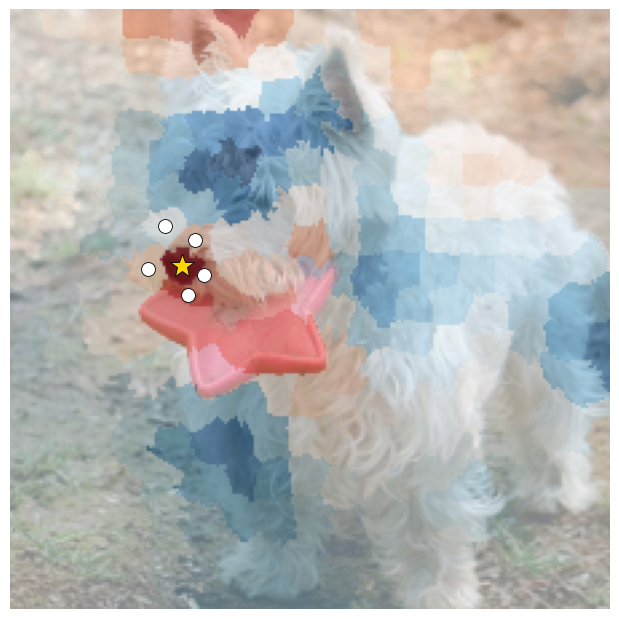

Saved â†’ output\seed_selection.png


In [ ]:
# â”€â”€ Figure: score heatmap + seed/neighbour markers â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
score_map = np.zeros(segs.shape, dtype=np.float32)
for seg_id, score in scores.items():
    score_map[segs == seg_id] = score
abs_max = float(np.abs(score_map).max()) or 1.0

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(img_np)
ax.imshow(score_map, cmap="RdBu_r", vmin=-abs_max, vmax=abs_max, alpha=SCORE_ALPHA)
ax.axis("off")

# Seed star
ax.plot(
    seed_cx,
    seed_cy,
    "*",
    color="gold",
    markersize=SEED_MARKER_SIZE,
    markeredgecolor="black",
    markeredgewidth=0.6,
    zorder=5,
)

# Neighbour circles
for nb_id in seed_neighbors:
    nx, ny = centroid(nb_id)
    ax.plot(
        nx,
        ny,
        "o",
        color="white",
        markersize=NEIGHBOR_MARKER_SIZE,
        markeredgecolor="black",
        markeredgewidth=0.6,
        zorder=4,
    )

fig.tight_layout(pad=0)
fig.savefig(OUT / "seed_selection.png", dpi=150, bbox_inches="tight")
fig.savefig(OUT / "seed_selection.pdf", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved â†’ {OUT / 'seed_selection.png'}")

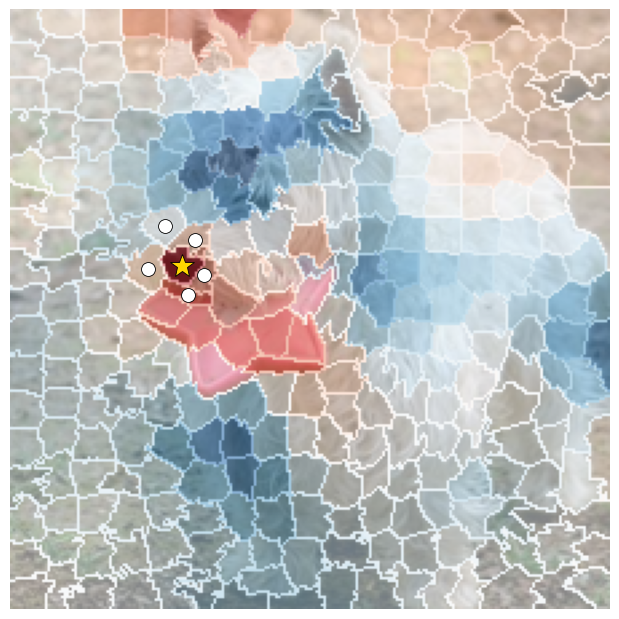

Saved â†’ output\seed_selection_boundaries.png


In [ ]:
# â”€â”€ Optional: same figure with segment boundaries visible â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
boundaries = _segment_boundaries(segs)
seg_overlay = img_np.copy()
seg_overlay[boundaries] = 1.0

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(seg_overlay)
ax.imshow(score_map, cmap="RdBu_r", vmin=-abs_max, vmax=abs_max, alpha=SCORE_ALPHA)
ax.axis("off")

ax.plot(
    seed_cx,
    seed_cy,
    "*",
    color="gold",
    markersize=SEED_MARKER_SIZE,
    markeredgecolor="black",
    markeredgewidth=0.6,
    zorder=5,
)
for nb_id in seed_neighbors:
    nx, ny = centroid(nb_id)
    ax.plot(
        nx,
        ny,
        "o",
        color="white",
        markersize=NEIGHBOR_MARKER_SIZE,
        markeredgecolor="black",
        markeredgewidth=0.6,
        zorder=4,
    )

fig.tight_layout(pad=0)
fig.savefig(OUT / "seed_selection_boundaries.png", dpi=150, bbox_inches="tight")
fig.savefig(OUT / "seed_selection_boundaries.pdf", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved â†’ {OUT / 'seed_selection_boundaries.png'}")